# Constraint cosmological parameters and cosmic baryons

In [1]:
import sys
sys.path.append('../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Show data

In [2]:
data=pd.read_csv('../Data/FRB.csv')
data

,FRB,z,DM_ext,From
0,FRB 20180814A,0.06800,73.30,Fan
1,FRB 20181030A,0.00385,32.30,Fan
2,FRB 20220529A,0.18390,176.00,Fan
3,FRB 20220610A,1.01600,1397.15,Fan
4,FRB 20220717A,0.36295,489.04,Fan
...,...,...,...,...
112,FRB 20231204A,0.06440,159.94,CHIME2025
113,FRB 20231206A,0.06590,370.12,CHIME2025
114,FRB 20231223C,0.10590,87.07,CHIME2025
115,FRB 20231229A,0.01900,110.98,CHIME2025


In [3]:
print(len(data))
data = data[data['FRB'] != 'FRB 20190520B']
data = data[data['FRB'] != 'FRB 20220831A']
data = data[data['z'] >= 0.2]
# data = data[data['FRB'] == 'FRB 20230521B']
print(len(data))
data.head()

117
56


,FRB,z,DM_ext,From
3,FRB 20220610A,1.01600,1397.15,Fan
4,FRB 20220717A,0.36295,489.04,Fan
6,FRB 20230521B,1.35400,1174.10,Fan
7,FRB 20230814A,0.55300,561.60,Fan
8,FRB 20231220A,0.33550,411.30,Fan


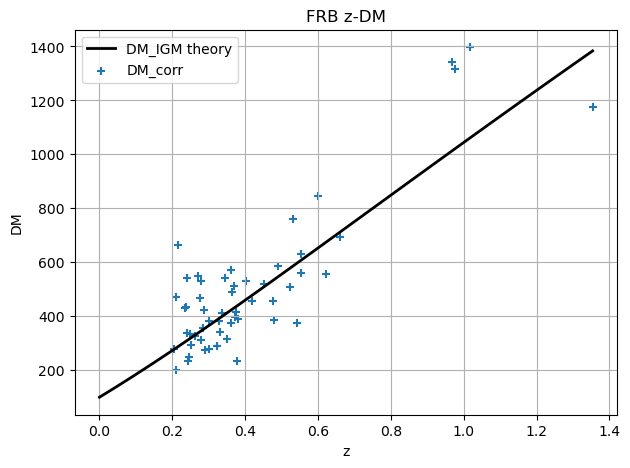

In [4]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0, np.max(data['z']), 100)

DM_theory = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)

ax1.plot(z_range, 100+DM_theory, lw=2, c='black', label='DM_IGM theory')
ax1.scatter(data['z'], data['DM_ext'], s=40, marker='+', label='DM_corr')  
ax1.set_xlabel('z')
ax1.set_ylabel('DM')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

# Preparation

In [5]:
Sigmas=np.load('./interpolation/sigmas.npy')
Vars_sqrt=np.load('./interpolation/Vars_sqrt.npy')
C0s=np.load('./interpolation/C0s.npy')
As=np.load('./interpolation/As.npy')

In [6]:
sigma_var = interpolate.interp1d(Vars_sqrt, Sigmas, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

Text(0, 0.5, 'Sigma')

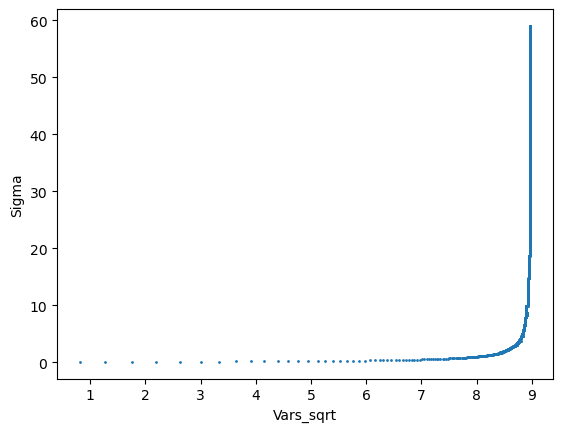

In [7]:
plt.scatter(Vars_sqrt, Sigmas,s=1)
plt.xlabel('Vars_sqrt')
plt.ylabel('Sigma')

In [8]:
var=4
# 4.185538686543227
print(sigma_var(np.sqrt(var)))

0.13013422032517716


In [9]:
C0_sigma = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [10]:
A_sigma = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


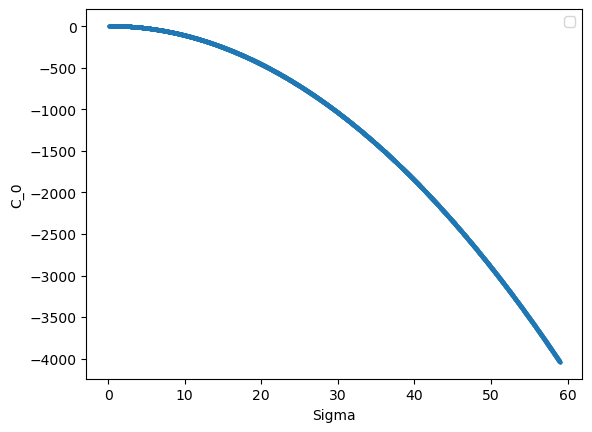

In [11]:
plt.scatter(Sigmas, C0s,  s=3)

plt.ylabel('C_0')
plt.xlabel('Sigma')
plt.legend()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


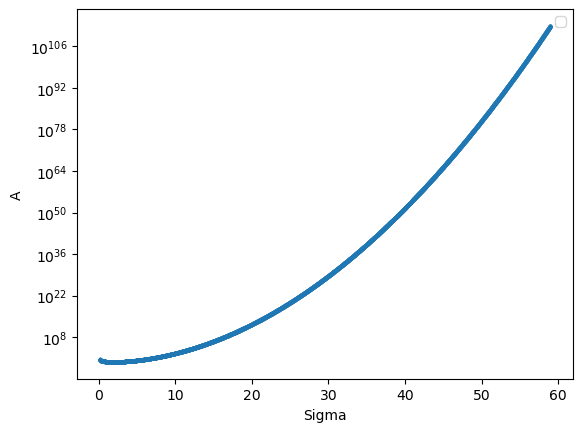

In [12]:
plt.scatter(Sigmas, As,  s=3)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
plt.legend()

plt.show()

plot

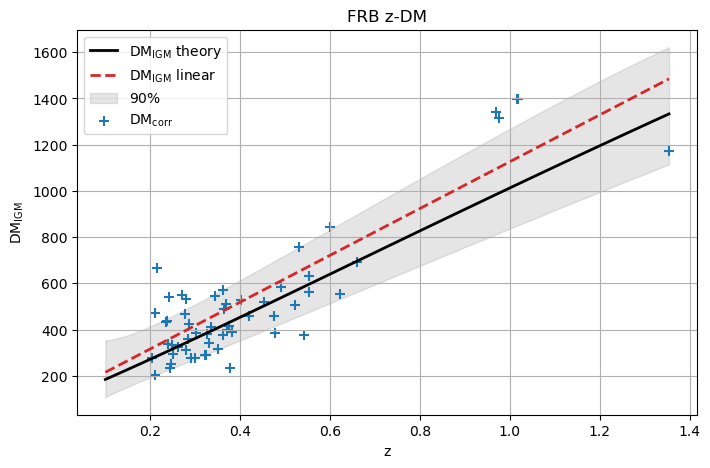

In [13]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0.1, np.max(data['z']), 100)
y_high = np.zeros_like(z_range)
y_low = np.zeros_like(z_range)

a = 1012.73
b = 113.70
DM_linear = a*z_range+b

DM_theory = np.zeros_like(z_range)

## The range of DM_cosmic (the y-axis)
DM_cosmic_range = np.linspace(0.01, 2000, 2000)
    

for idx, z in enumerate(z_range):
    sigma=sigma_var(np.sqrt(f_variance_delta(F=5.5, z=z)))
    C0 = C0_sigma(sigma)
    A = A_sigma(sigma)
    DM_theory[idx] = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0, f_IGM_0 = f_IGM)
    
    ## The range of DM_cosmic (the y-axis)
    # DM_cosmic_range = np.linspace(0.01, np.max(data['DM_ext'])/(DM_theory[idx]), 1000)
    p=pdf_DM_cosmo(DM_cosmic_range/(100+DM_theory[idx]), C_0=C0, A=A, sigma=sigma)
    
    ## Calculating the 5% and 95% limits, to plot the shaded area
    cdf = np.cumsum(normalise(p))
    y_high[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.95))]
    y_low[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.05))]
    

ax1.plot(z_range, 100+DM_theory, lw=2, c='black', label=r'DM$_{\rm IGM}$ theory')
ax1.plot(z_range, DM_linear, lw=2, ls='--', c='tab:red', label=r'DM$_{\rm IGM}$ linear')
ax1.fill_between(z_range, y_low, y_high, alpha=0.2, color='grey', label=r'$90\%$')


ax1.scatter(data['z'], data['DM_ext'], s=50, marker='+', label=r'DM$_{\rm corr}$')  

ax1.set_xlabel('z')
ax1.set_ylabel(r'DM$_{\rm IGM}$')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

Constrain $H_0 \Omega_0 f_{IGM}=const $

In [20]:
def DM_IGM_H0_O_b_f_IGM(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z, Om, w):
        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    integral, _ = quad(integrand, 0, z, args=(Om, w))
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [17]:
z=1.00
print(DM_IGM_O_bh_70(z=z, O_bh_70=OMEGA_BARYONS*HUBBLE/70.0))
print(DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HUBBLE*OMEGA_BARYONS*f_IGM))

944.0949564541271
912.8582288974072


In [18]:
def calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    # print([f_variance_delta(F,z),sigma,C_0, A])
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [19]:
# def calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
#     DM_host_array = np.linspace(0.01, DM_frb_max * (1+z)-0.01, 5000)

#     ## Host calculation
#     pdf_host = pdf_DM_host(DM_host_array, e_mu, sigma_host)
    
#     ## Cosmic calculation    
#     DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
#     Deltas = (DM_frb_max-DM_host_array/(1+z))/DM_th
#     C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s,sigma_met="Mac")
#     A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3,sigma_met="Mac")
#     pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z), met="Mac")
    
#     ## Combine together    
#     prob = np.trapz(pdf_host*pdf_cosmic, x=DM_host_array)
    
#     ## Transform to probabilities
#     # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
#     return prob/DM_th

In [20]:
def calculate_dm_probability_num_HOf_v3(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0, DM_frb_max / DM_th, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    p_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    p_cosmic[np.isnan(p_cosmic)] = 0
    
    # print([f_variance_delta(F,z),sigma,C_0, A])
    
    ## Host calculation
    p_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    p_host[np.isnan(p_host)] = 0
    
    ## Combine together    
    prob = np.trapz(p_host*p_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [21]:
DM_frb_max=1174.1
z=1.354
F=10
HOf=3.0
e_mu=200
sigma_host=0.6

# print(calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host))
print(calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host))
print(calculate_dm_probability_num_HOf_v3(DM_frb_max, z, F, HOf, e_mu, sigma_host))

0.0020514109767481147
0.002054058413407659


In [22]:
HOf_fiducial=70*OMEGA_BARYONS*0.9
print(HOf_fiducial)

3.0851100000000002


In [ ]:
# F defined before
F_array=np.linspace(5.0, 18.0, 20)
sigma_host_array=np.linspace(0.2,1.4,20)
e_mu_array=np.linspace(50, 250, 20)
HOf_array=np.linspace(1.0, 5.0, 20)

F_4D, HOf_array_4D, sigma_host_4D, e_mu_4D = np.meshgrid(
    F_array, HOf_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

F_h, h_F = np.meshgrid(F_array, HOf_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_4D: {F_4D.shape}, HOf_array_4D: {HOf_array_4D.shape}, sigma_host_4D: {sigma_host_4D.shape}, e_mu_4D: {e_mu_4D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_4D: (20, 20, 20, 20), HOf_array_4D: (20, 20, 20, 20), sigma_host_4D: (20, 20, 20, 20), e_mu_4D: (20, 20, 20, 20)
Shape of F_h: (20, 20), h_F: (20, 20), F_sigma: (20, 20), sigma_F: (20, 20), F_e_mu: (20, 20), e_mu_F: (20, 20)


In [24]:
# posterior_4D = 1.0 + np.zeros_like(F_4D, dtype= np.float128)
log_posterior_4D = np.zeros_like(F_4D, dtype= np.float64)
# Calculate total iterations for progress bar
# total_iterations = len(data['FRB']) * len(F_array) * len(HOf_array) * len(sigma_host_array) * len(e_mu_array)
total_iterations = len(data['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (F, HOf, sigma_host, e_mu)
    for F in F_array
    for HOf in HOf_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in data.iterrows():
    # Iterate through parameter combinations
    for idx, (F, HOf, sigma_host, e_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_num_HOf_v3(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=F,
            HOf=HOf,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        
        # Calculate indices for 4D array
        i = idx // (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))
        j = (idx % (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
        k = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
        l = idx % len(e_mu_array)
    
        # Store result
        # print([i,j,k,l])
        # posterior_4D[i,j,k,l] = posterior_4D[i,j,k,l] * prob
        if prob > 0:
            log_posterior_4D[i,j,k,l] += np.log(prob)
        else:
            log_posterior_4D[i,j,k,l] = -np.inf
        
        # Update progress bar
        # pbar.update(1)
    
        # Optional: Add parameter values to progress bar description
        pbar.set_description(f"idx={_}, FRB={row['FRB']}, z={row['z']}, F={F:.2f}, HOf={HOf:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}, prob={prob:.2f}")
    
    # # log_posterior = np.log(posterior_4D)
    log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
    if np.isfinite(log_sum):
        log_posterior_4D = log_posterior_4D - log_sum
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
            
    # posterior_4D_tot=np.sum(posterior_4D)
    # if posterior_4D_tot>0:
    #     posterior_4D=posterior_4D/posterior_4D_tot
    # else:
    #     print(f"posterior_4D_tot={posterior_4D_tot} at FRB={row['FRB']}")
    #     break
    
    pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

idx=3, FRB=FRB 20220610A, z=1.016, F=5.00, HOf=3.95, σ=1.40, μ=250.00, prob=0.00:   0%|          | 0/56 [01:02<?, ?it/s]/Users/zhuge/Documents/GitHub/FRB_cosmology/code/../Python_scripts/cosmo_support.py:376: RuntimeWarning: invalid value encountered in log
  np.exp(-(np.log(non_zero_DM)-mu)**2/(2*(sigma_host**2)))
FRB=FRB 20231025B: 100%|██████████| 56/56 [27:31:16<00:00, 1769.23s/it]                                                                     


In [25]:
log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
if np.isfinite(log_sum):
    posterior_4D = np.exp(log_posterior_4D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

np.save("./posterior/posterior_const_sqrt.npy", posterior_4D)

In [26]:
posterior_4D = np.load("./posterior/posterior_const_sqrt.npy")

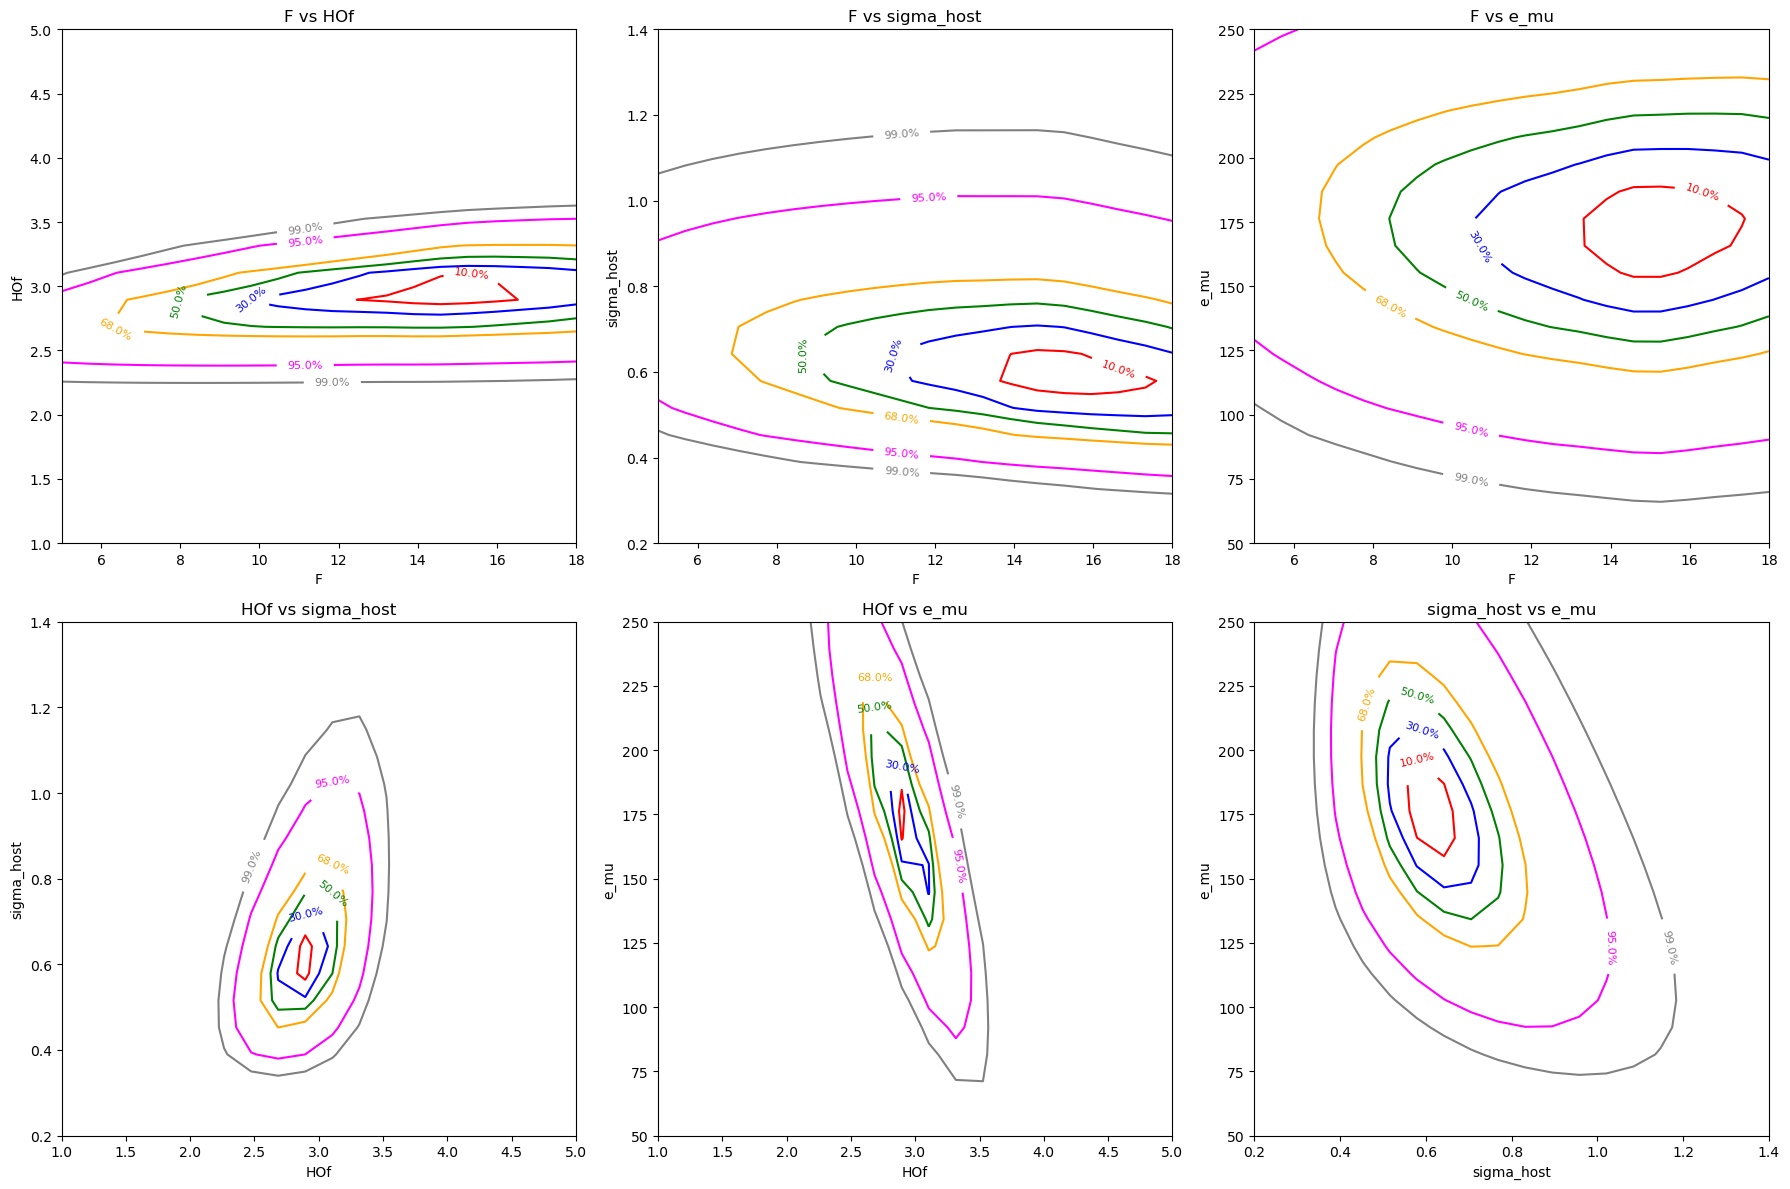

In [27]:
from scipy.stats import chi2

confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "HOf", (2, 3), F_h, h_F),
    ("F", "sigma_host", (1, 3), F_sigma, sigma_F),
    ("F", "e_mu", (1, 2), F_e_mu, e_mu_F),
    ("HOf", "sigma_host", (0, 3), h_sigma, sigma_h),
    ("HOf", "e_mu", (0, 2), h_e_mu, e_mu_h),
    ("sigma_host", "e_mu", (0, 1), sigma_e_mu, e_mu_sigma)
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)

plt.tight_layout()
plt.show()

Constrain $H_0 \Omega_0 f_{IGM}=H_0 \Omega_0 f_{IGM,0}(1+a
\cdot z)$

In [14]:
def DM_IGM_H0_O_b_f_IGM_linear(z, H0_O_b_f_IGM, a, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z, Om, w):
        return (1+a*z)*(1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*KM_2_MPC*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    z_array = np.linspace(0, z, 1000)
    integral = np.trapz(integrand(z_array, Om, w), x=z_array)
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

In [29]:
# def calculate_dm_probability_num_HOf_linear(DM_frb_max, z, F, HOf, a ,e_mu, sigma_host):
    
#     DM_host_array = np.linspace(0.01, DM_frb_max * (1+z)-0.01, 5000)

#     ## Host calculation
#     pdf_host = pdf_DM_host(DM_host_array, e_mu, sigma_host)
    
#     ## Cosmic calculation    
#     DM_th = DM_IGM_H0_O_b_f_IGM_linear(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
#     Deltas = (DM_frb_max-DM_host_array/(1+z))/DM_th
#     C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s,sigma_met="Mac")
#     A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3,sigma_met="Mac")
#     pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z, met="Mac"))
    
#     ## Combine together    
#     prob = np.trapz(pdf_host*pdf_cosmic, x=DM_host_array)
    
#     ## Transform to probabilities
#     # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
#     return prob/DM_th

In [15]:
def calculate_dm_probability_num_HOf_linear_fast(DM_frb_max, z, F, HOf, a ,e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_linear(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0, DM_frb_max / DM_th, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=C0_sigma(sigma)
    A = A_sigma(sigma)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [16]:
def calculate_dm_probability_num_HOf_linear_v2(DM_frb_max, z, F, HOf, a ,e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_linear(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0, DM_frb_max / DM_th, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=C0_sigma(sigma)
    A = A_sigma(sigma)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [17]:
DM_frb_max=489.15
z=0.36295
F=10
HOf=2.89
e_mu=250
sigma_host=1.4
a=0.01

# print(calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host))
print(calculate_dm_probability_num_HOf_linear_fast(DM_frb_max, z, F, HOf, a, e_mu, sigma_host))

0.0015358816014633236


In [18]:
F_array=np.linspace(5.0, 18.0, 10)
sigma_host_array=np.linspace(0.2,1.4,10)
e_mu_array=np.linspace(50, 250, 10)
HOf_array=np.linspace(1.0,5.0, 10)
a_array=np.linspace(0, 0.15, 20)

F_5D, HOf_array_5D, a_array_5D, sigma_host_5D, e_mu_5D = np.meshgrid(
    F_array, HOf_array, a_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

F_h, h_F = np.meshgrid(F_array, HOf_array)
F_a, a_F = np.meshgrid(F_array, a_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_a, a_h = np.meshgrid(HOf_array, a_array)
h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)

a_sigma, sigma_a = np.meshgrid(a_array, sigma_host_array)
a_e_mu, e_mu_a = np.meshgrid(a_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_5D: {F_5D.shape}, HOf_array_5D: {HOf_array_5D.shape}, a_array_5D: {a_array_5D.shape}, sigma_host_5D: {sigma_host_5D.shape}, e_mu_5D: {e_mu_5D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_a: {F_a.shape}, a_F: {a_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_5D: (10, 10, 20, 10, 10), HOf_array_5D: (10, 10, 20, 10, 10), a_array_5D: (10, 10, 20, 10, 10), sigma_host_5D: (10, 10, 20, 10, 10), e_mu_5D: (10, 10, 20, 10, 10)
Shape of F_h: (10, 10), h_F: (10, 10), F_a: (20, 10), a_F: (20, 10), F_sigma: (10, 10), sigma_F: (10, 10), F_e_mu: (10, 10), e_mu_F: (10, 10)


In [ ]:
# posterior_5D = 1.0 + np.zeros_like(F_5D, dtype= np.float128)
log_posterior_5D = np.zeros_like(F_5D, dtype= np.float64)
# Calculate total iterations for progress bar
# total_iterations = len(data['FRB']) * len(F_array) * len(HOf_array) * len(a_array) * len(sigma_host_array) * len(e_mu_array)
total_iterations = len(data['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (F, HOf, a, sigma_host, e_mu)
    for F in F_array
    for HOf in HOf_array
    for a in a_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in data.iterrows():
    # Iterate through parameter combinations
    for idx, (F, HOf, a, sigma_host, e_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_num_HOf_linear_fast(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=F,
            HOf=HOf,
            a=a,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        
        # Calculate indices for 5D array
        i = idx // (len(HOf_array) * len(a_array) * len(sigma_host_array) * len(e_mu_array))
        j = (idx % (len(HOf_array) * len(a_array) * len(sigma_host_array) * len(e_mu_array))) // (len(a_array) * len(sigma_host_array) * len(e_mu_array))
        k = (idx % (len(a_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
        l = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
        m = idx % len(e_mu_array)
    
        # Store result
        # posterior_5D[i,j,k,l,m] = posterior_5D[i,j,k,l,m] * prob
        if prob > 0:
            log_posterior_5D[i,j,k,l,m] += np.log(prob)
        else:
            log_posterior_5D[i,j,k,l,m] = -np.inf
        
        # # Update progress bar
        # pbar.update(1)
    
        # # Optional: Add parameter values to progress bar description
        pbar.set_description(f"idx={_}, FRB={row['FRB']}, F={F:.2f}, HOf={HOf:.2f}, a={a:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f},prob={prob:.2f}")
    
    log_sum = np.logaddexp.reduce(log_posterior_5D.ravel())
    if np.isfinite(log_sum):
        log_posterior_5D = log_posterior_5D - log_sum
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
    
    # posterior_5D_tot=np.sum(posterior_5D)
    # if posterior_5D_tot>0:
    #     posterior_5D=posterior_5D/posterior_5D_tot
    # else:
    #     print(f"posterior_5D_tot={posterior_5D_tot} at FRB={row['FRB']}")
    #     break
    
    pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

idx=3, FRB=FRB 20220610A, F=5.00, HOf=1.89, a=0.01, σ=1.40, μ=250.00,prob=0.00:   0%|          | 0/56 [00:11<?, ?it/s]   /mnt/d/Document/Research/FRB/cosmology/FRB_cosmology/code/../Python_scripts/cosmo_support.py:376: RuntimeWarning: invalid value encountered in log
  np.exp(-(np.log(non_zero_DM)-mu)**2/(2*(sigma_host**2)))
idx=7, FRB=FRB 20230814A, F=6.44, HOf=3.67, a=0.02, σ=0.73, μ=183.33,prob=0.00:   5%|▌         | 3/56 [19:11<5:20:27, 362.78s/it] 

In [1]:
log_sum = np.logaddexp.reduce(log_posterior_5D.ravel())
if np.isfinite(log_sum):
    posterior_5D = np.exp(log_posterior_5D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

np.save("./posterior/posterior_linear.npy", posterior_5D)

NameError: name 'np' is not defined

In [41]:
posterior_5D = np.load("./posterior/posterior_linear.npy")
print(np.sum(posterior_5D))

1.0000000000013305


In [42]:
print(posterior_5D[5,:,3,1,6])

[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 1.87199951e-288 0.00000000e+000]


/tmp/ipykernel_29084/1337276825.py:26: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


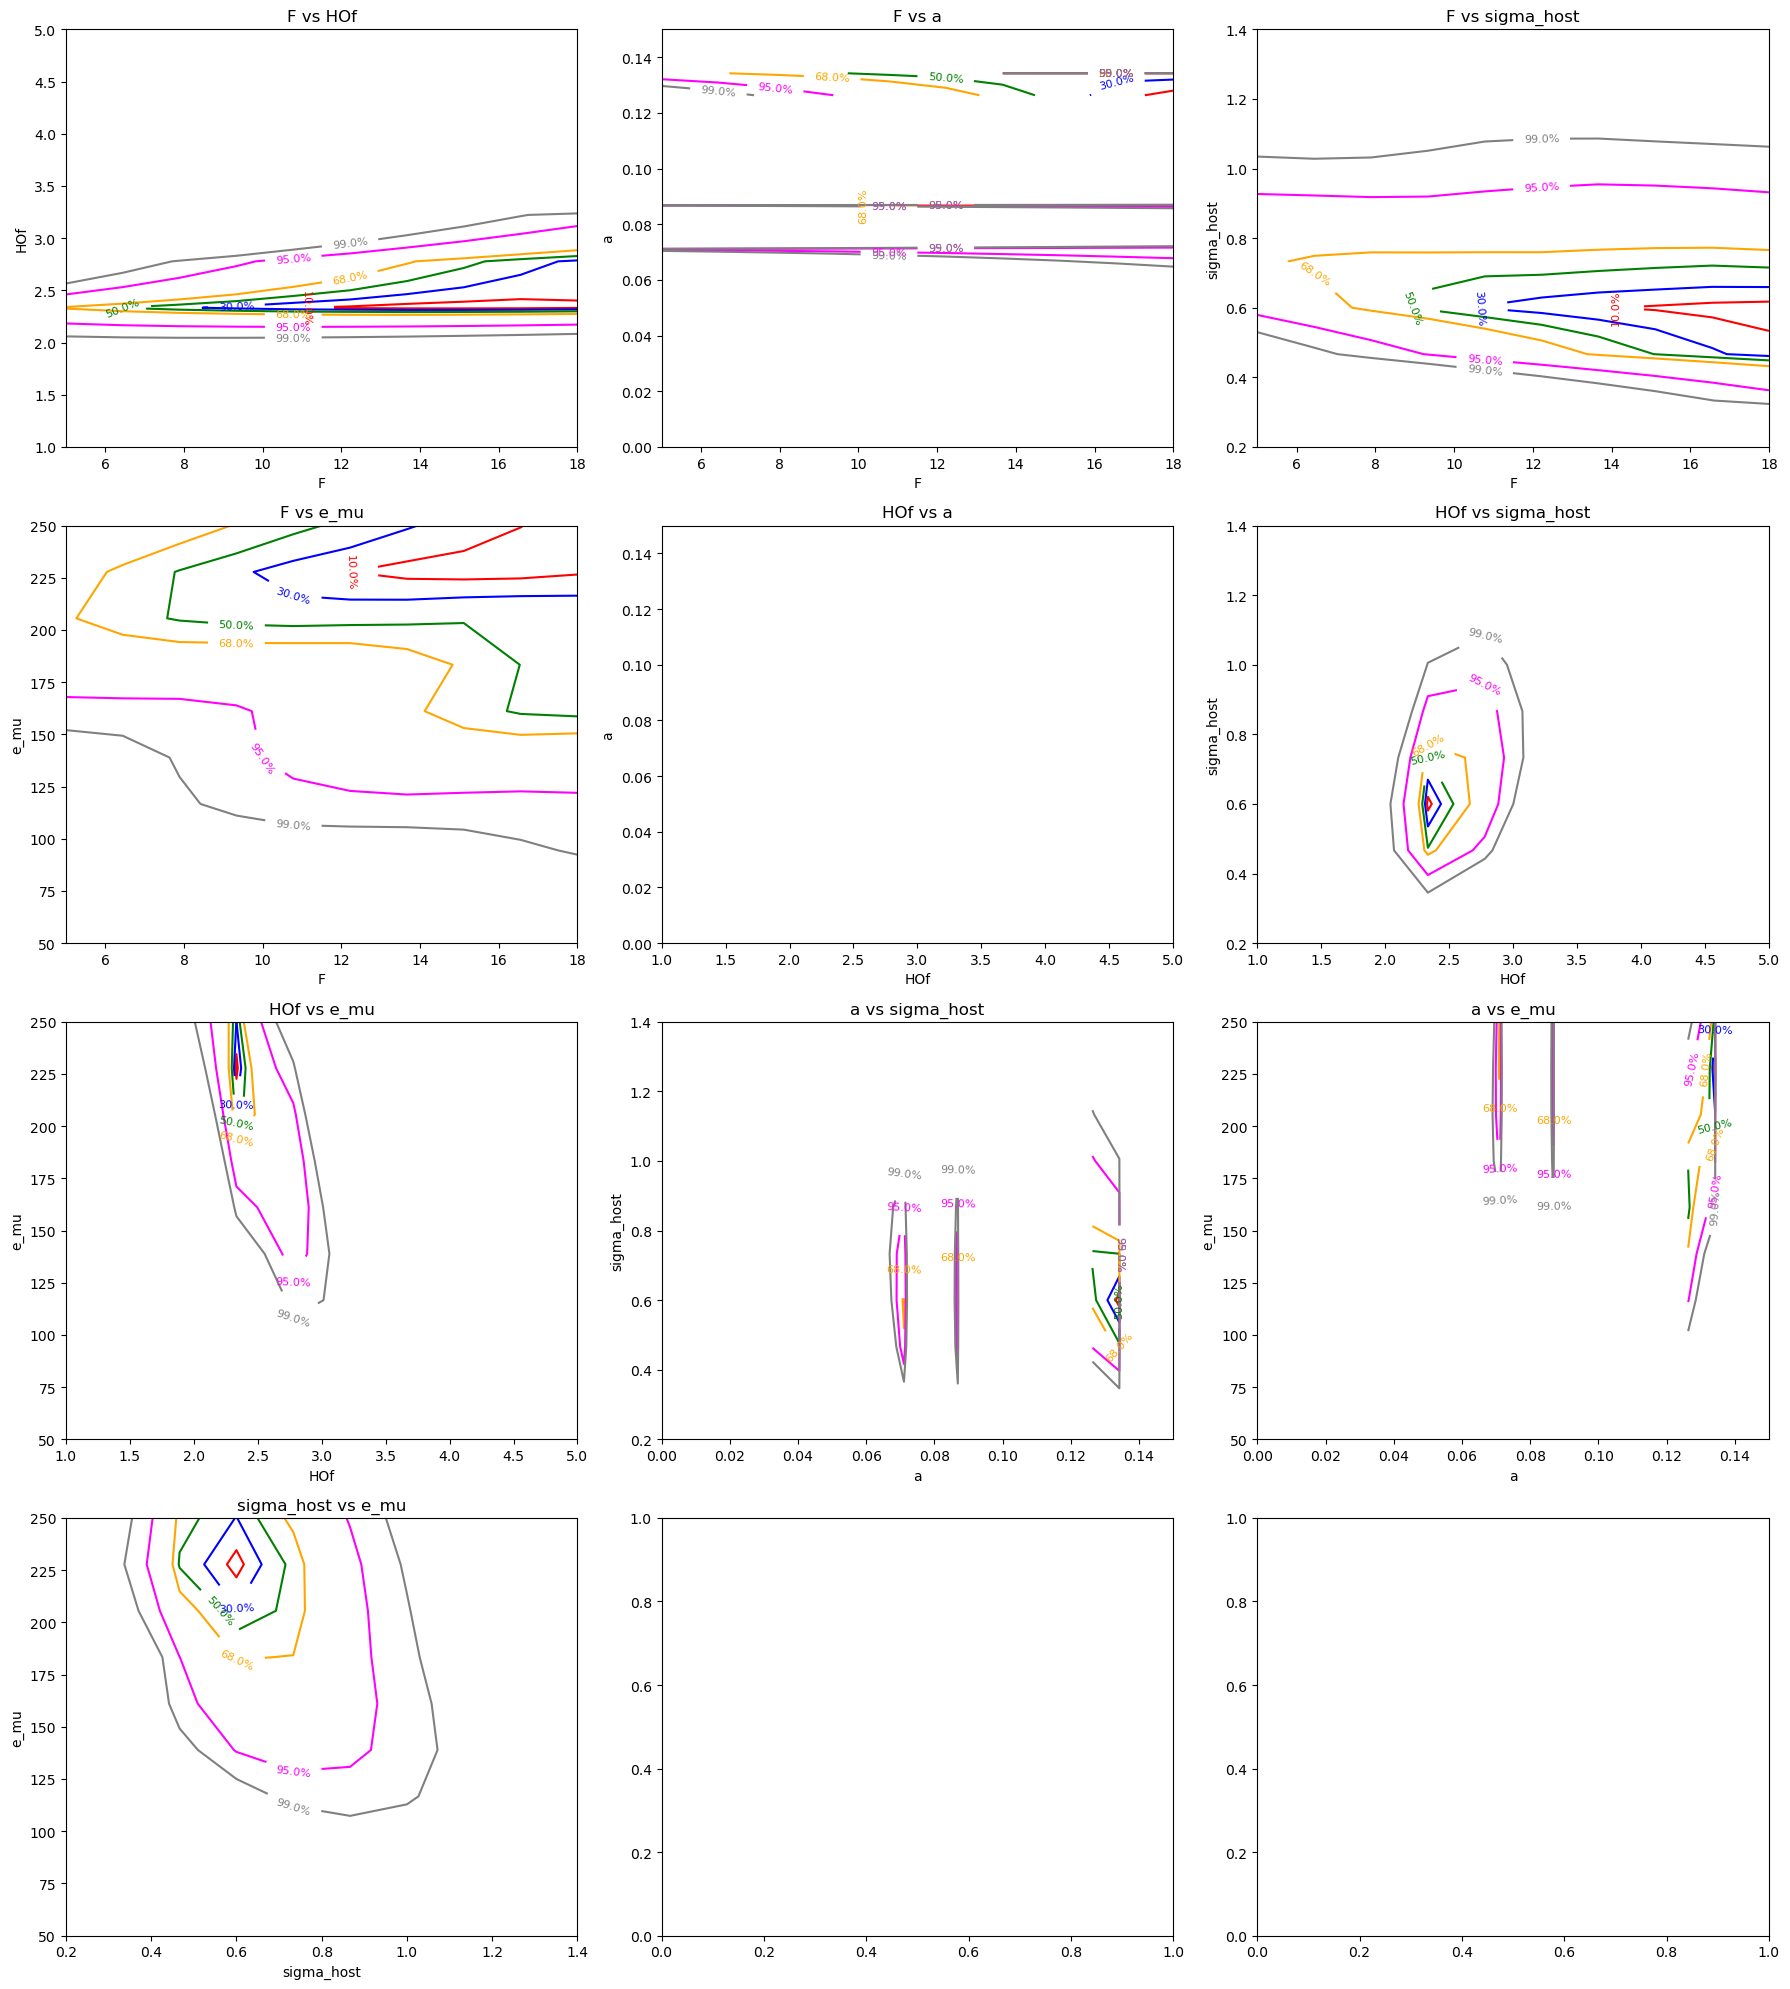

In [43]:
from scipy.stats import chi2

confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "HOf", (2, 3, 4), F_h, h_F),
    ("F", "a", (1, 3, 4), F_a, a_F),
    ("F", "sigma_host", (1, 2, 4), F_sigma, sigma_F),
    ("F", "e_mu", (1, 2, 3), F_e_mu, e_mu_F),
    ("HOf", "a", (0, 3, 4), h_a, a_h),
    ("HOf", "sigma_host", (0, 2, 4), h_sigma, sigma_h),
    ("HOf", "e_mu", (0, 2, 3), h_e_mu, e_mu_h),
    ("a", "sigma_host", (0, 1, 4), a_sigma, sigma_a),
    ("a", "e_mu", (0, 1, 3), a_e_mu, e_mu_a),
    ("sigma_host", "e_mu", (0, 1, 2), sigma_e_mu, e_mu_sigma)
]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_5D, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)

plt.tight_layout()
plt.show()